In [ ]:
#Without using libraries

import math
from collections import Counter

# Simple dataset
# Features: [Outlook, Temperature]
X = [
    ['Sunny', 'Hot'],
    ['Sunny', 'Hot'],
    ['Overcast', 'Hot'],
    ['Rain', 'Mild'],
    ['Rain', 'Cool']
]

y = ['No', 'No', 'Yes', 'Yes', 'Yes']

In [ ]:
#Entropy
def calculate_entropy(labels):
    total = len(labels)
    counts = Counter(labels)

    entropy = 0
    for label in counts:
        p = counts[label] / total
        entropy -= p * math.log2(p)

    return entropy

#Information Gain
def information_gain(X, y, feature_index):
    base_entropy = calculate_entropy(y)
    total = len(y)

    values = set(row[feature_index] for row in X)
    weighted_entropy = 0

    for value in values:
        subset_y = [
            y[i] for i in range(total)
            if X[i][feature_index] == value
        ]

        weighted_entropy += (len(subset_y) / total) * calculate_entropy(subset_y)

    return base_entropy - weighted_entropy

In [ ]:
#Build the tree
def build_tree(X, y, feature_names):
    # Case 1: all outputs same
    if len(set(y)) == 1:
        return y[0]

    # Case 2: no features left
    if len(feature_names) == 0:
        return Counter(y).most_common(1)[0][0]

    # Find best feature
    gains = []
    for i in range(len(feature_names)):
        gain = information_gain(X, y, i)
        gains.append(gain)

    best_feature_index = gains.index(max(gains))
    best_feature_name = feature_names[best_feature_index]

    tree = {best_feature_name: {}}

    # Split dataset
    feature_values = set(row[best_feature_index] for row in X)

    for value in feature_values:
        new_X = []
        new_y = []

        for i in range(len(X)):
            if X[i][best_feature_index] == value:
                new_X.append(X[i][:best_feature_index] + X[i][best_feature_index+1:])
                new_y.append(y[i])

        new_features = feature_names[:best_feature_index] + feature_names[best_feature_index+1:]

        tree[best_feature_name][value] = build_tree(new_X, new_y, new_features)

    return tree

In [ ]:
features = ['Outlook', 'Temperature']
decision_tree = build_tree(X, y, features)

print(decision_tree)

{'Outlook': {'Sunny': 'No', 'Rain': 'Yes', 'Overcast': 'Yes'}}


In [ ]:
#Visualization
from graphviz import Digraph

def visualize_manual_tree(tree):
    dot = Digraph()
    root = list(tree.keys())[0]

    # Root node
    dot.node(root, root)

    # Child nodes
    for value, result in tree[root].items():
        child = f"{root}_{value}"
        dot.node(child, result)
        dot.edge(root, child, label=value)

    return dot

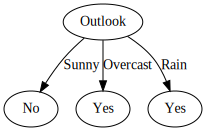

In [ ]:
decision_tree = {
    'Outlook': {
        'Sunny': 'No',
        'Overcast': 'Yes',
        'Rain': 'Yes'
    }
}

visualize_manual_tree(decision_tree)

In [ ]:
#using libraries

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X_iris = iris.data        # 150 samples
y_iris = iris.target     # 150 samples

X_train, X_test, y_train, y_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.2,
    random_state=42,
    stratify=y_iris
)

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


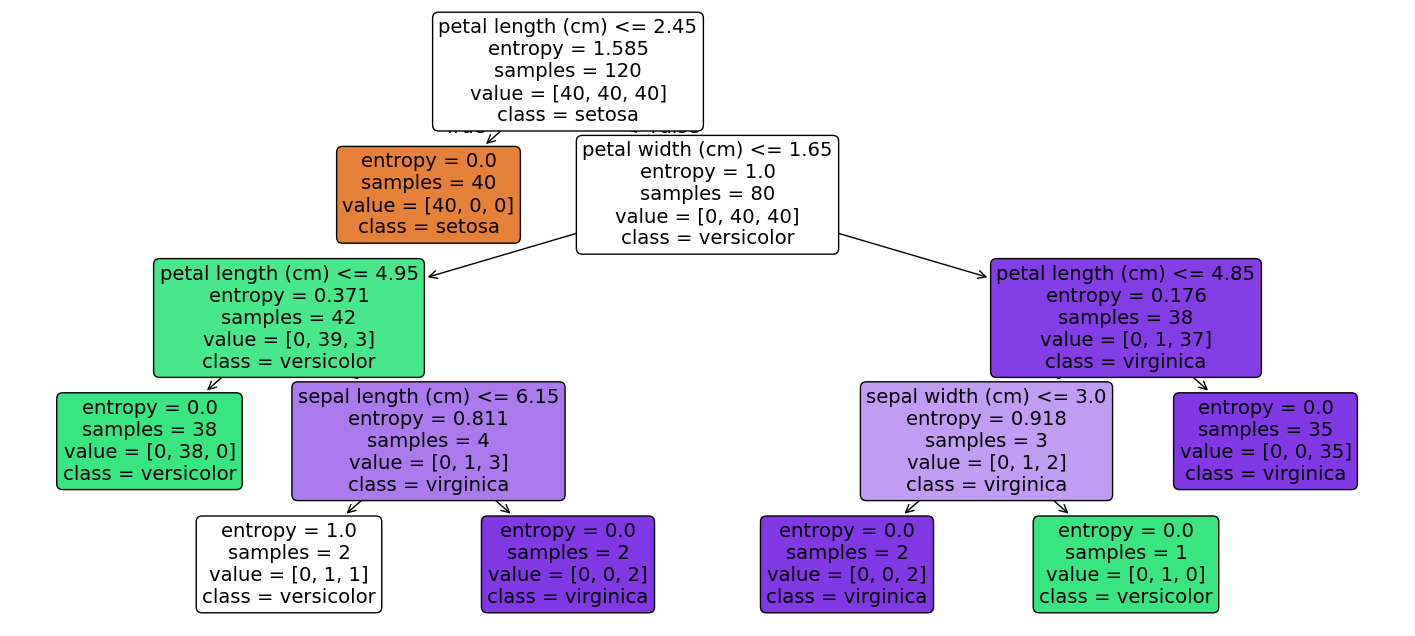

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.show()